In [1]:
import numpy as np
import anndata as ad
import seaborn as sns, matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import mannwhitneyu
import scanpy as sc
import decoupler as dc
sc.set_figure_params(figsize=(3, 3), frameon=False)

/rds/general/user/ztb25/home/miniforge3/envs/DE/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def present_genes(adata, genes, verbose=True):
    """Return only the genes that exist in adata.var_names; log the rest.
    Keeps batch jobs from dying when a marker was dropped during HVG selection."""
    keep = [g for g in genes if g in adata.var_names]
    missing = [g for g in genes if g not in adata.var_names]
    if missing and verbose:
        print("skipping genes not in var_names:", missing)
    return keep

In [ ]:
adata = sc.read("/rds/general/user/ztb25/home/PBMC_datasets/integrated_adata_scANVI.h5ad")


In [4]:
adata

AnnData object with n_obs × n_vars = 880872 × 12711
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'hvg', 'neighbors', 'pca', 'sample_combined_colors', 'scANVI', 'umap'
    obsm: 'X_pca', 'X_scANVI', 'X_umap_scANVI', 'X_umap_unintegrated'
    varm: 'PCs'
    layers: 'counts', 'log1p_norm'
    obsp: 'connectivities', 'connectivities_unintegrated', 'distances', 'distances_unintegrated', 'scAN

In [5]:
# Bringing back diagnosis column, needed for composition analysis, that got dropped at concatenation.

# the per-dataset files 
files = {
    "1": "/rds/general/user/ztb25/home/PBMC_datasets/1/PBMC1_clustering.h5ad",
    "4": "/rds/general/user/ztb25/home/PBMC_datasets/4/PBMC4_clustering.h5ad",
    "5": "/rds/general/user/ztb25/home/PBMC_datasets/5/PBMC5_clustering.h5ad",
    "6": "/rds/general/user/ztb25/home/PBMC_datasets/6/PBMC6_clustering.h5ad",
}

diag_map = {}
for ds, path in files.items():
    a = ad.read_h5ad(path, backed="r")
    integrated_barcodes = a.obs_names + f"-{ds}"
    if "diagnosis" in a.obs.columns:
        diags = a.obs["diagnosis"].astype(str).tolist()
    else:
        diags = ["CTRL"] * a.n_obs          # dataset 6 — no column, all controls
    diag_map.update(dict(zip(integrated_barcodes, diags)))
    a.file.close()

adata.obs["diagnosis"] = adata.obs_names.map(diag_map)

In [6]:
import gc
del diag_map                
try:
    del a                    
except NameError:
    pass
gc.collect()

adata.obs["diagnosis"] = adata.obs["diagnosis"].astype("category")


In [7]:
# ## monocytes lineage

# monocytes = ["Classical monocytes", "Non-classical monocytes"]
# adata_mono = adata[adata.obs["celltypist_cell_label_fine"].isin(monocytes)].copy()

# adata_mono


In [8]:
# trying with coarse label

adata_mono = adata[adata.obs["celltypist_cell_label_coarse"] == "Monocytes"].copy()

In [9]:
adata_mono.obs["celltypist_cell_label_fine"].value_counts()


celltypist_cell_label_fine
Classical monocytes        99931
Non-classical monocytes    27627
Monocytes                    214
Naive B cells                 53
Name: count, dtype: int64

In [10]:
#### Subclustering monocytes to see if we can get a better trajectory/labels (intermediate states)

# ---------------------------------------------------------------
# 1. Neighbour graph on the BATCH-CORRECTED latent, monocytes only.
#    Reusing scANVI (not a fresh PCA) keeps datasets mixed instead of
#    letting batch masquerade as a subcluster.
# ---------------------------------------------------------------
sc.pp.neighbors(adata_mono, use_rep="X_scANVI", n_neighbors=15)


/var/tmp/pbs.3287799.pbs-7/ipykernel_1681231/4008315796.py:8: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_mono, resolution=res, key_added=f"mono_leiden_{res}")


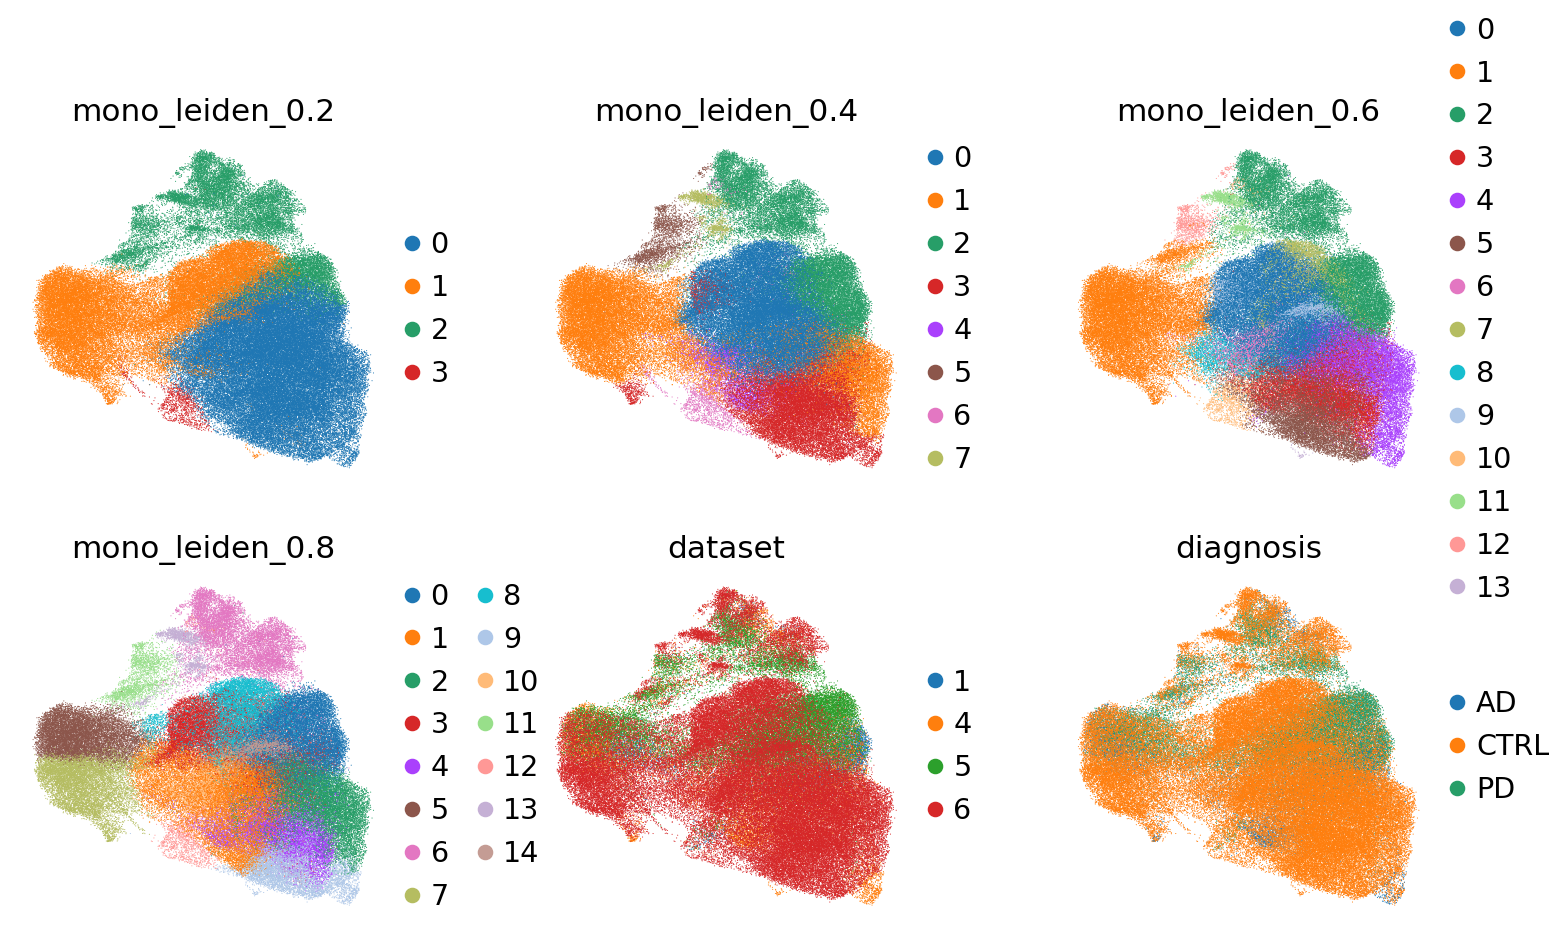

In [11]:

# ---------------------------------------------------------------
# 2. Leiden at several resolutions. Intermediate monocytes are a
#    SMALL bridge population, so they only appear once resolution is
#    high enough to split the main cloud — but too high shatters the
#    continuum. Sweep and inspect rather than trusting one value.
# ---------------------------------------------------------------
for res in [0.2, 0.4, 0.6, 0.8]:
    sc.tl.leiden(adata_mono, resolution=res, key_added=f"mono_leiden_{res}")

sc.tl.umap(adata_mono)

sc.pl.umap(
    adata_mono,
    color=["mono_leiden_0.2", "mono_leiden_0.4", "mono_leiden_0.6", "mono_leiden_0.8",
           "dataset", "diagnosis"],           # dataset/diagnosis: check clusters aren't batch/condition artefacts
    ncols=3,
)


missing: ['HLA-DRA']


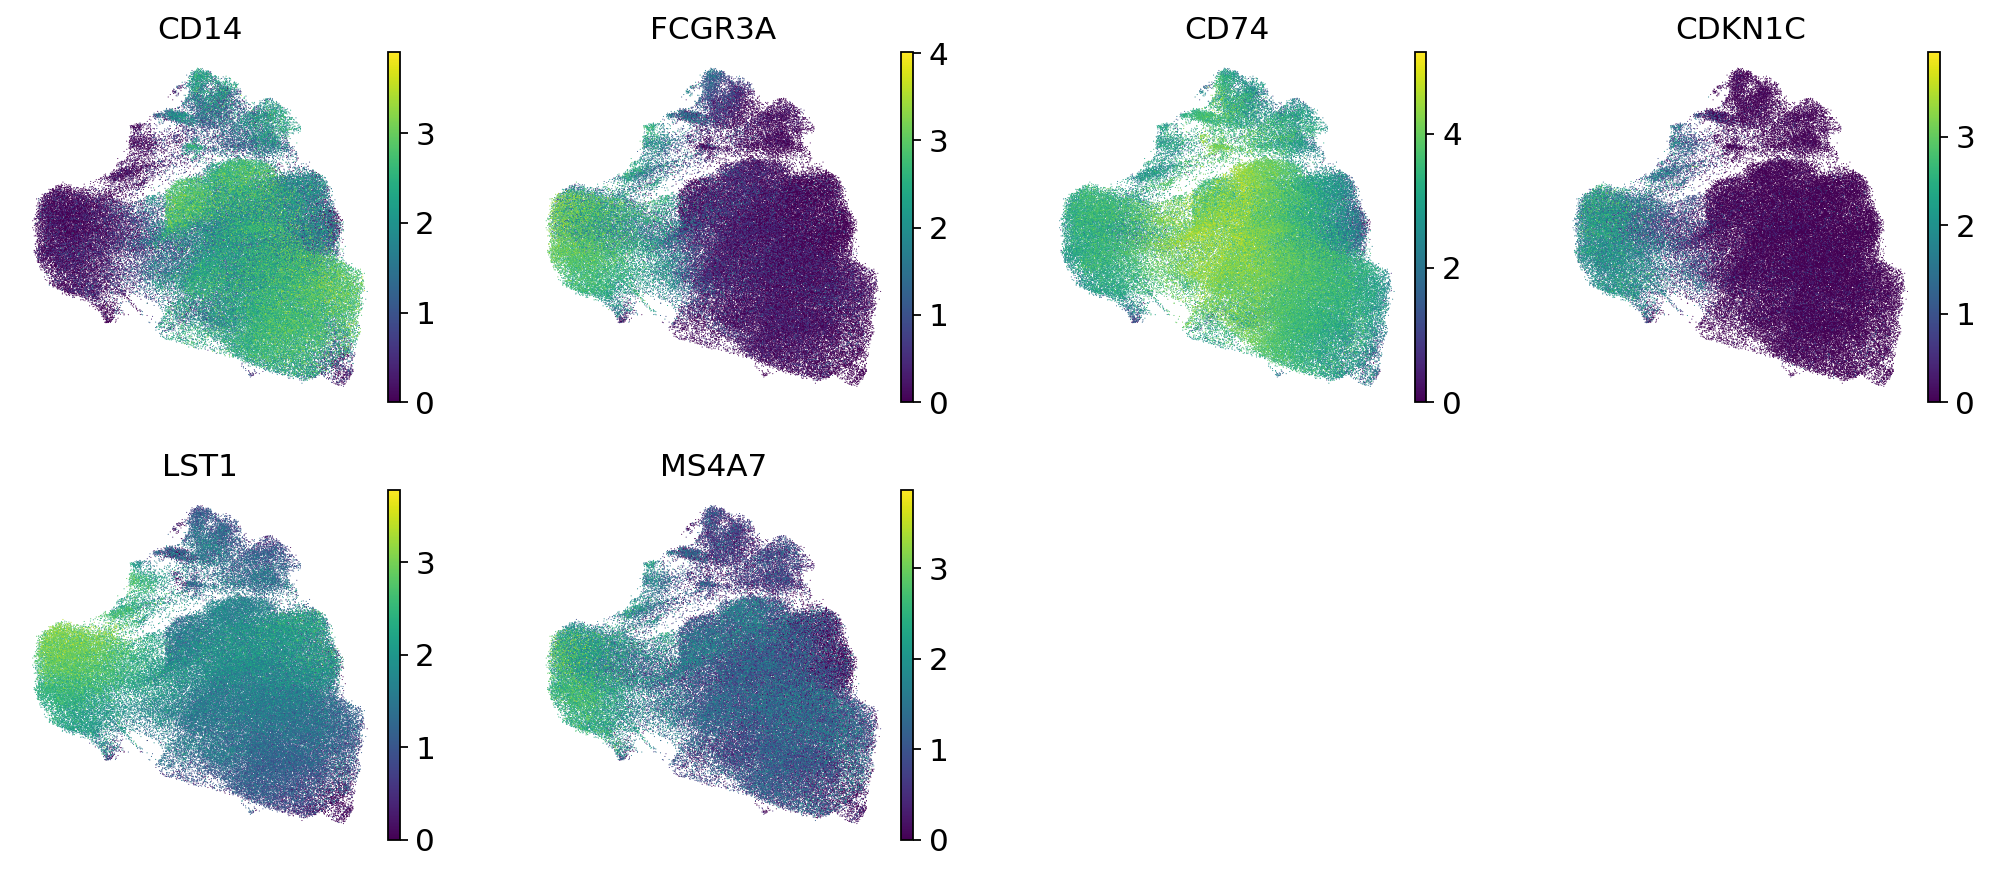

In [12]:

# ---------------------------------------------------------------
# 3. Overlay the maturation-axis markers to LOCATE the intermediate cluster.
#    Classical:    CD14 high, FCGR3A (CD16) low
#    Intermediate: CD14 high  AND FCGR3A present, high MHC-II (HLA-DRA/CD74)
#    Non-classical:CD14 low,  FCGR3A high, CDKN1C / LST1 / MS4A7 high
# ---------------------------------------------------------------


markers = ["CD14","FCGR3A","HLA-DRA","CD74",            # classical / intermediate signal
           "CDKN1C","LST1","MS4A7"]                     # non-classical signal
present = [g for g in markers if g in adata_mono.var_names]
missing = [g for g in markers if g not in adata_mono.var_names]
print("missing:", missing)
sc.pl.umap(adata_mono, color=present, layer="log1p_norm", ncols=4)


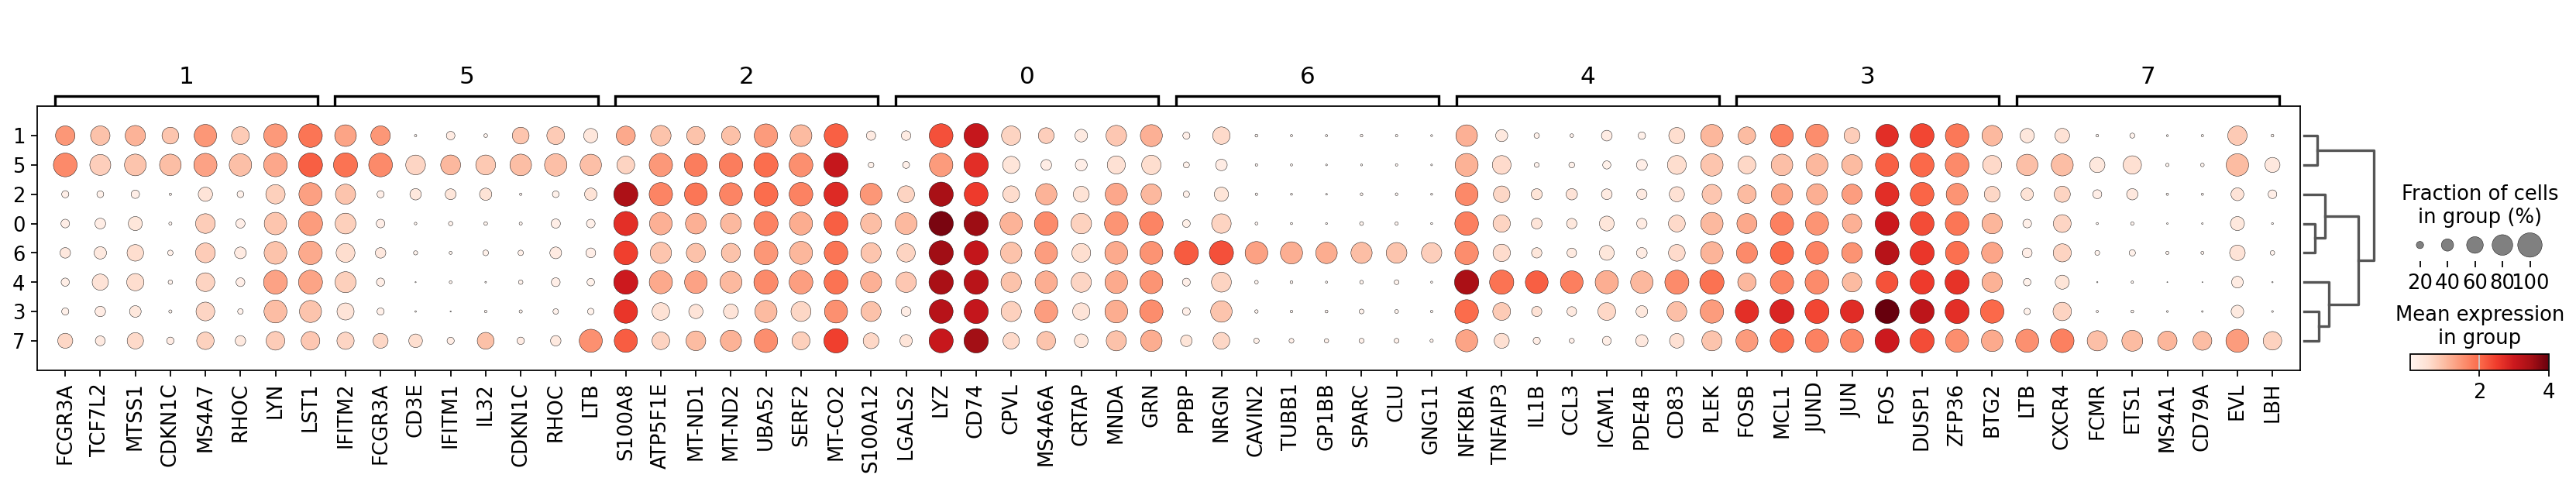

skipping genes not in var_names: ['HLA-DRA']


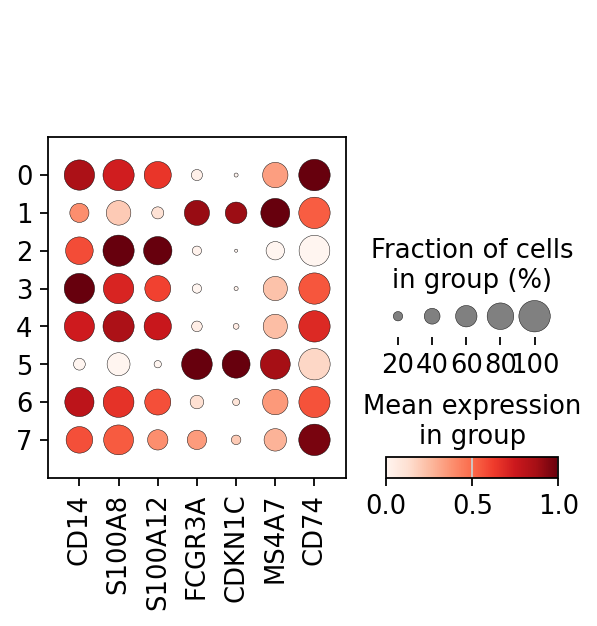

In [13]:

# ---------------------------------------------------------------
# 4. DEGs per subcluster (on log-normalised expression) to confirm identity.
#    Pick the resolution from step 2 that gives ONE coherent middle cluster.
# ---------------------------------------------------------------
chosen = "mono_leiden_0.4"       # <-- set after looking at the plots
sc.tl.rank_genes_groups(adata_mono, chosen, method="wilcoxon", use_raw=False, layer="log1p_norm")
sc.pl.rank_genes_groups_dotplot(adata_mono, n_genes=8)

# quick co-expression view: intermediate cells are the CD14+/FCGR3A+ double-positives
mono_markers = ["CD14", "S100A8", "S100A12",   # classical-leaning
                "FCGR3A", "CDKN1C", "MS4A7",    # non-classical-leaning
                "HLA-DRA", "CD74"]             # MHC-II, elevated in intermediate

present = [g for g in mono_markers if g in adata_mono.var_names]
missing = [g for g in mono_markers if g not in adata_mono.var_names]
if missing:
    print("skipping genes not in var_names:", missing)   # visible in the job's .out log

sc.pl.dotplot(
    adata_mono,
    var_names=present,
    groupby=chosen,
    layer="log1p_norm",
    standard_scale="var",   # matches your other clustering notebooks
)


In [14]:
# use scanvi latent space to infer pseudotime (batch corrected)

sc.pp.neighbors(adata_mono, use_rep="X_scANVI") # compute neighbors on the corrected latent
sc.tl.diffmap(adata_mono) # generates X_diffmap, which is a trajectory aware dimensionality reduction (distance in diffusion-map space ≈ how likely a cell is to transition into another cell along the manifold.)

# set the root cell for pseudotime inference to be a classical monocyte
adata_mono.uns["iroot"] = np.flatnonzero(
    adata_mono.obs["celltypist_cell_label_fine"] == "Classical monocytes")[0]

# compute pseudotime using diffusion pseudotime (DPT)
sc.tl.dpt(adata_mono) 

# subset-specific umap (for visualisation)
sc.tl.umap(adata_mono)

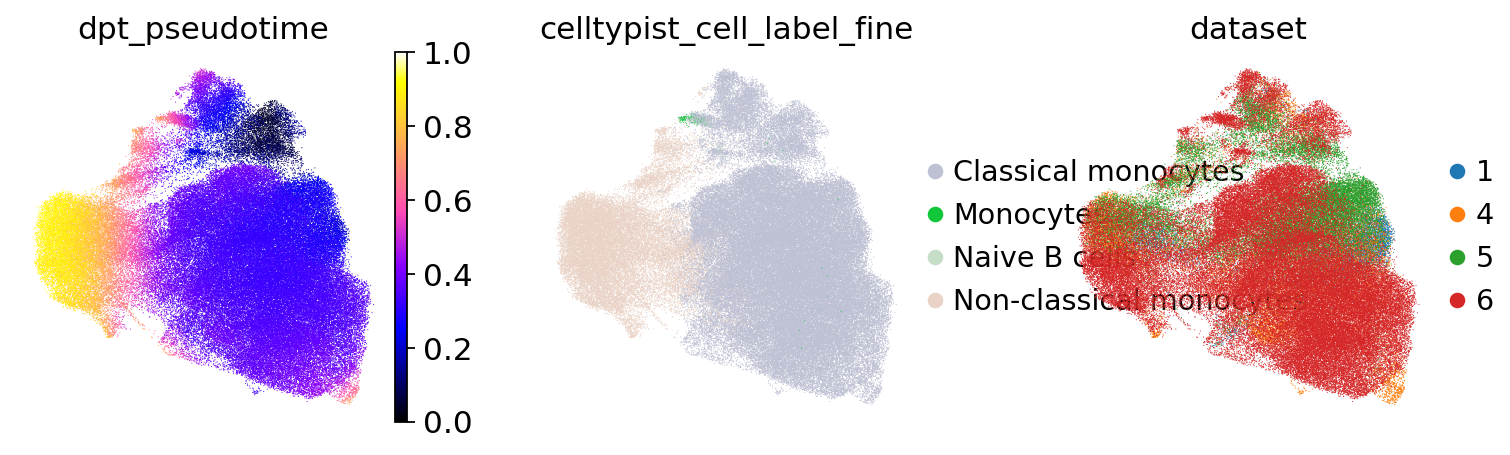

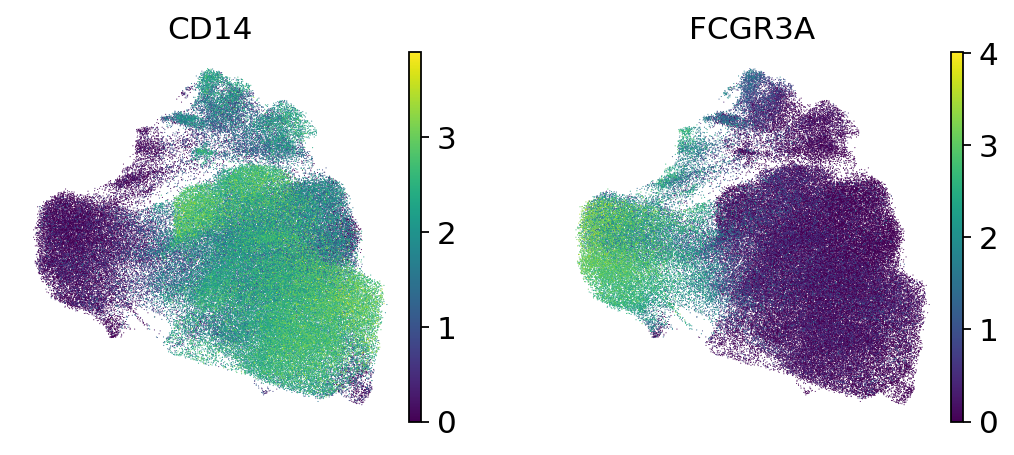

In [15]:
sc.pl.embedding(adata_mono, basis="umap",
                color=["dpt_pseudotime", "celltypist_cell_label_fine", "dataset"],
                color_map="gnuplot2")
# markers should form a gradient along pseudotime; dataset should be MIXED (not segregated)
sc.pl.embedding(adata_mono, basis="umap", color=["CD14", "FCGR3A"], layer="log1p_norm")

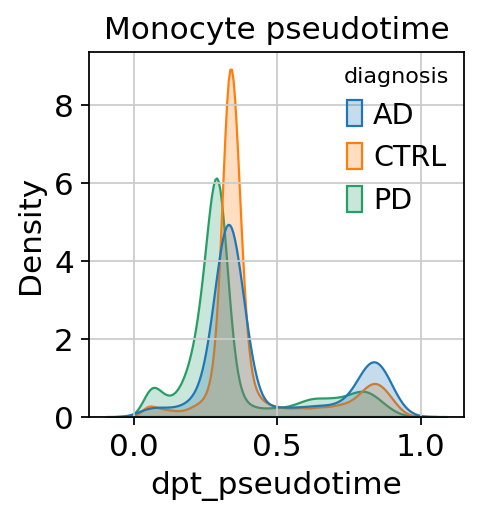

In [16]:

sns.kdeplot(data=adata_mono.obs, x="dpt_pseudotime", hue="diagnosis", common_norm=False, fill=True)
plt.title("Monocyte pseudotime"); plt.show()


In [17]:
# Statistical test for difference in pseudotime between PD and CTRL donors

# 1. one summary per donor (median pseudotime), carry diagnosis + cell count
per_donor = (adata_mono.obs
             .groupby("sample_combined")
             .agg(median_pt=("dpt_pseudotime", "median"),
                  diagnosis=("diagnosis", "first"),
                  n_cells=("dpt_pseudotime", "size")))

per_donor = per_donor[per_donor["n_cells"] >= 20]   # drop donors with too few monocytes (unstable median)

# 2. donor-level test (n = donors)
pd_vals   = per_donor.loc[per_donor.diagnosis == "PD",   "median_pt"]
ctrl_vals = per_donor.loc[per_donor.diagnosis == "CTRL", "median_pt"]
U, p = mannwhitneyu(pd_vals, ctrl_vals, alternative="two-sided")

print(f"donors: PD={len(pd_vals)}, CTRL={len(ctrl_vals)}")
print(f"median pseudotime: PD={pd_vals.median():.3f}, CTRL={ctrl_vals.median():.3f}")
print(f"Mann-Whitney U={U:.0f}, p={p:.3g}")


donors: PD=18, CTRL=57
median pseudotime: PD=0.295, CTRL=0.334
Mann-Whitney U=79, p=7.54e-08


/var/tmp/pbs.3287799.pbs-7/ipykernel_1681231/2699022231.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sample_combined")


In [18]:
# rank-biserial correlation (Cliff's delta) — simple, bounded [-1,1]
delta = 2*U/(len(pd_vals)*len(ctrl_vals)) - 1
print(f"Cliff's delta = {delta:.3f}")   # sign = direction, |value| = separation


Cliff's delta = -0.846


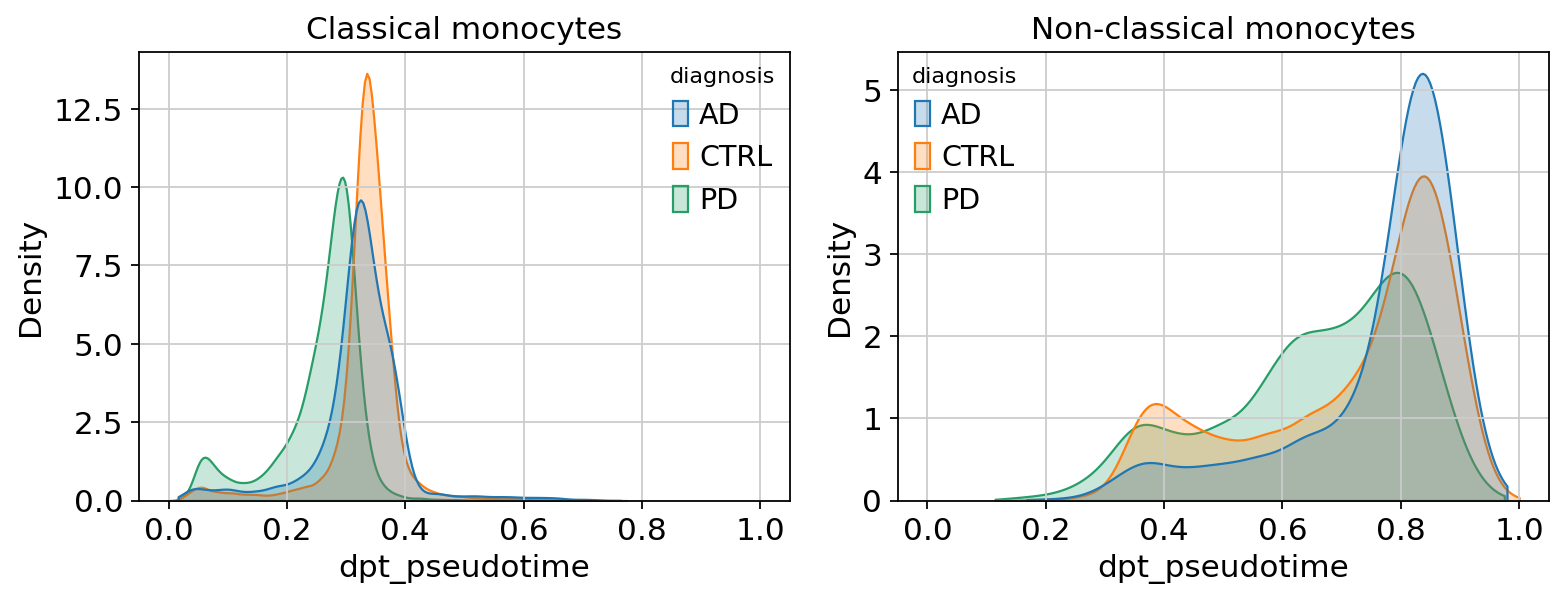

Classical monocytes: PD=18, CTRL=57 donors | median PD=0.287, CTRL=0.323 | MWU U=80, p=8.08e-08
Non-classical monocytes: PD=18, CTRL=56 donors | median PD=0.698, CTRL=0.791 | MWU U=192, p=8.69e-05


In [19]:
subgroup_col = "celltypist_cell_label_fine"     # or your manual leiden subclusters
subgroups    = ["Classical monocytes", "Non-classical monocytes"]

# ---- 1. Faceted density plot: PD vs CTRL WITHIN each subgroup ----
fig, axes = plt.subplots(1, len(subgroups), figsize=(5 * len(subgroups), 4), sharex=True)
for ax, sg in zip(axes, subgroups):
    sub = adata_mono.obs[adata_mono.obs[subgroup_col] == sg]
    sns.kdeplot(data=sub, x="dpt_pseudotime", hue="diagnosis",
                common_norm=False, fill=True, cut=0, ax=ax)   # cut=0: don't smear past [0,1]
    ax.set_title(sg)
plt.tight_layout(); plt.show()

# ---- 2. Donor-level test WITHIN each subgroup (mirrors the plot) ----
# one median per donor PER SUBGROUP  -> note groupby now has TWO keys
per_donor_sg = (adata_mono.obs
                .groupby([subgroup_col, "sample_combined"], observed=True)
                .agg(median_pt=("dpt_pseudotime", "median"),
                     diagnosis=("diagnosis", "first"),
                     n_cells=("dpt_pseudotime", "size"))
                .reset_index())

per_donor_sg = per_donor_sg[per_donor_sg["n_cells"] >= 20]   # drop unstable donor medians

for sg in subgroups:
    d = per_donor_sg[per_donor_sg[subgroup_col] == sg]
    pd_vals   = d.loc[d.diagnosis == "PD",   "median_pt"]
    ctrl_vals = d.loc[d.diagnosis == "CTRL", "median_pt"]
    if len(pd_vals) < 3 or len(ctrl_vals) < 3:
        print(f"{sg}: too few donors (PD={len(pd_vals)}, CTRL={len(ctrl_vals)}) — skip")
        continue
    U, p = mannwhitneyu(pd_vals, ctrl_vals, alternative="two-sided")
    print(f"{sg}: PD={len(pd_vals)}, CTRL={len(ctrl_vals)} donors | "
          f"median PD={pd_vals.median():.3f}, CTRL={ctrl_vals.median():.3f} | "
          f"MWU U={U:.0f}, p={p:.3g}")


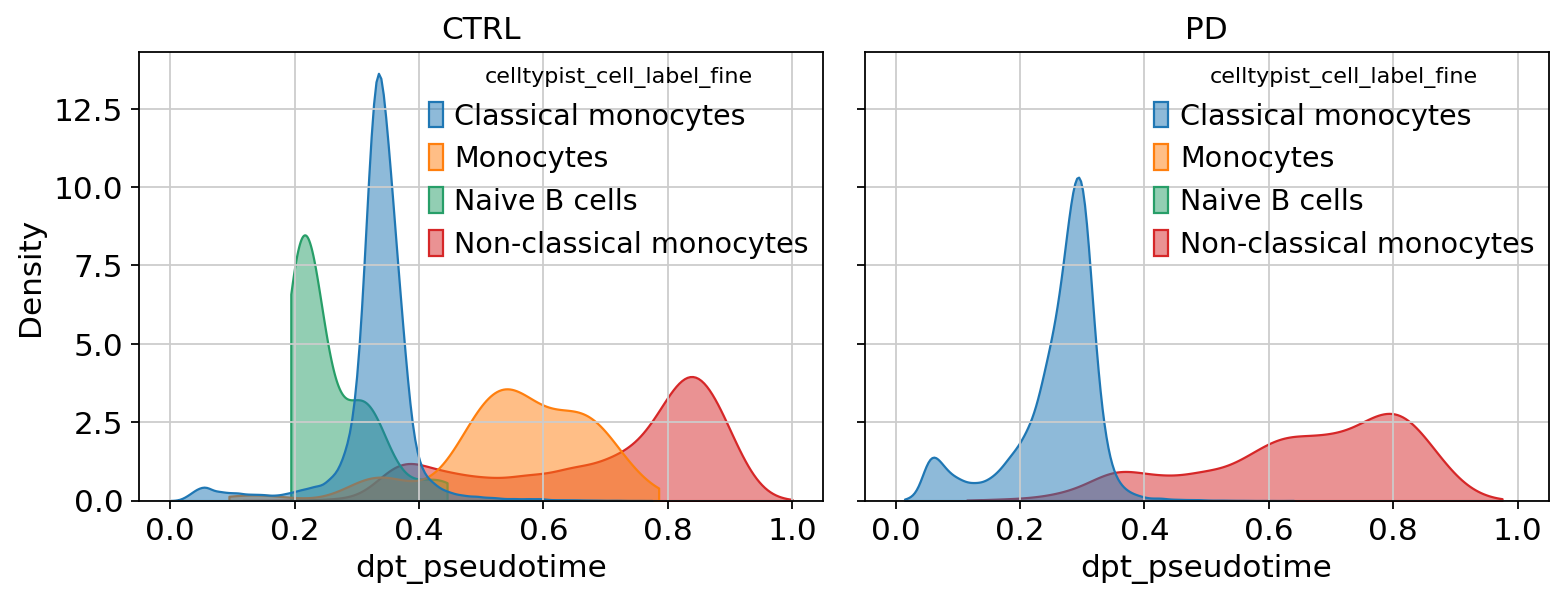

In [20]:
subgroup_col = "celltypist_cell_label_fine"     # or your manual leiden subclusters
diseases     = ["CTRL", "PD"]                    # one panel each; CTRL first as baseline

fig, axes = plt.subplots(1, len(diseases), figsize=(5 * len(diseases), 4),
                         sharex=True, sharey=True)
for ax, dz in zip(axes, diseases):
    sub = adata_mono.obs[adata_mono.obs["diagnosis"] == dz]
    sns.kdeplot(data=sub, x="dpt_pseudotime", hue=subgroup_col,
                common_norm=False, fill=True, cut=0, alpha=0.5, ax=ax)
    ax.set_title(dz)
plt.tight_layout(); plt.show()


In [21]:
# sc.pl.violin(
#     adata_mono,
#     keys=["dpt_pseudotime"],
#     groupby="celltypist_cell_label_fine",
#     rotation=45,
#     order=[
#         "Classical monocytes",
#         "Non-classical monocytes",
#     ],
# )

In [22]:
adata.obs["celltypist_cell_label_fine"].value_counts()

celltypist_cell_label_fine
Tcm/Naive helper T cells       276082
CD16+ NK cells                 130968
Classical monocytes            100198
Tem/Temra cytotoxic T cells     95091
Tem/Effector helper T cells     61507
Tem/Trm cytotoxic T cells       46223
Naive B cells                   42217
Non-classical monocytes         27627
Memory B cells                  24084
Regulatory T cells              23014
Tcm/Naive cytotoxic T cells     17502
MAIT cells                      13022
DC2                              6313
NK cells                         4075
pDC                              3805
Monocytes                        3687
Age-associated B cells           3124
Megakaryocytes/platelets          710
Plasma cells                      471
HSC/MPP                           428
ILC3                              405
ETP                               172
DC1                               131
Megakaryocyte precursor            16
Name: count, dtype: int64

In [23]:
### T cell lineage (CD4 and CD8 split)

cd4 = ["Tcm/Naive helper T cells",     # naive/central memory -> root
       "Tem/Effector helper T cells"   # effector (terminal)
       ] 

cd8 = ["Tcm/Naive cytotoxic T cells",  # naive/early -> root
       "Tem/Temra cytotoxic T cells",  # effector memory (intermediate)
       "Tem/Trm cytotoxic T cells"   # TEMRA = terminally differentiated(late)
       ] 

# t_cells = ["Tcm/Naive helper T cells", "Tem/Temra cytotoxic T cells", "Tem/Effector helper T cells", "Tem/Trm cytotoxic T cells", "Regulatory T cells", "Tcm/Naive cytotoxic T cells", "MAIT cells"]
adata_cd4 = adata[adata.obs["celltypist_cell_label_fine"].isin(cd4)].copy()

adata_cd8 = adata[adata.obs["celltypist_cell_label_fine"].isin(cd8)].copy()

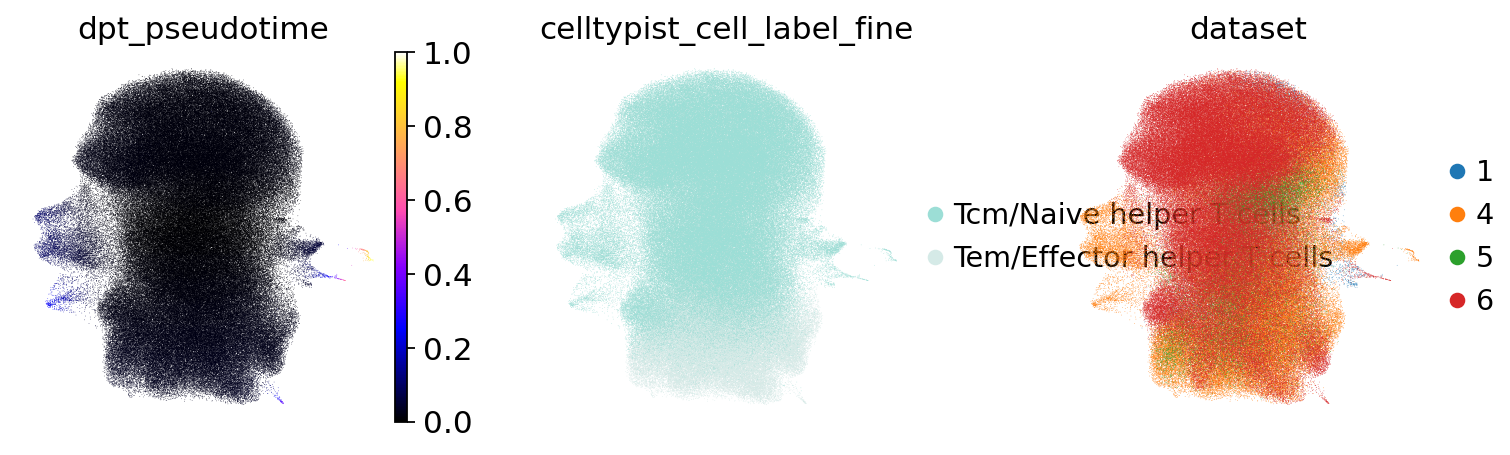

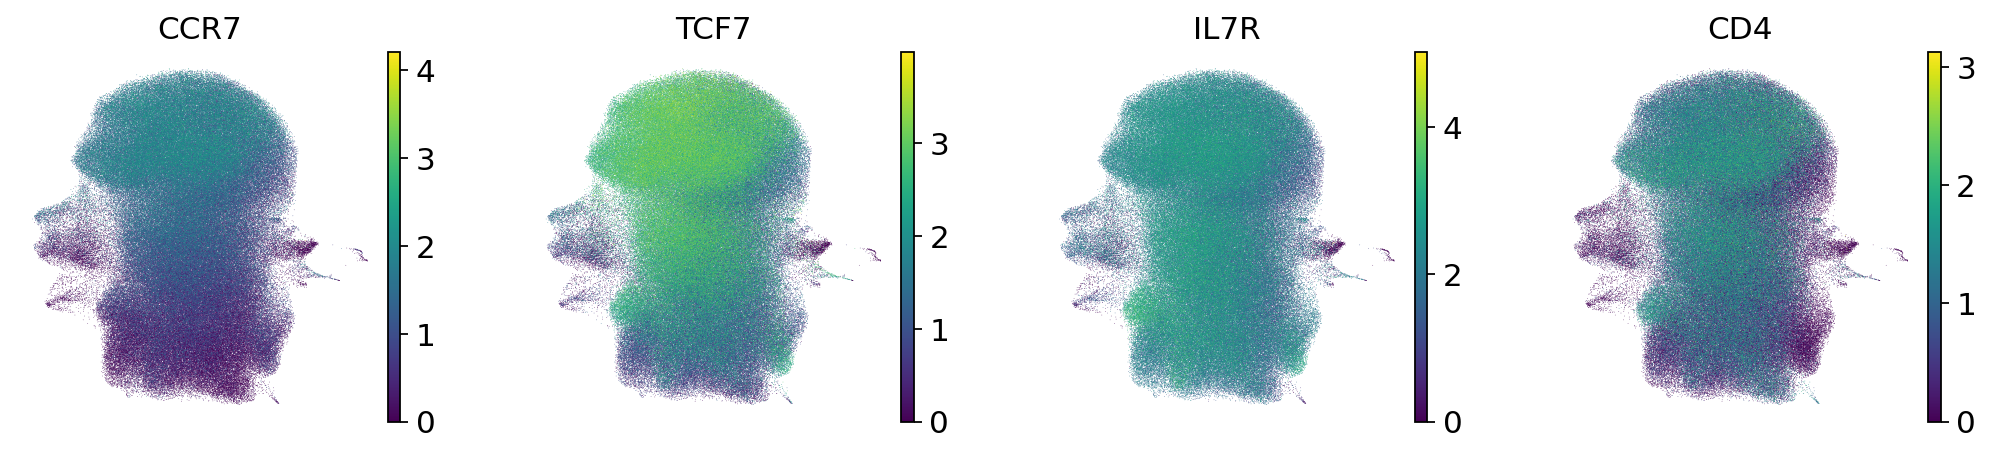

In [24]:
sc.pp.neighbors(adata_cd4, use_rep="X_scANVI") 
sc.tl.diffmap(adata_cd4) 

adata_cd4.uns["iroot"] = np.flatnonzero(
    adata_cd4.obs["celltypist_cell_label_fine"] == "Tcm/Naive helper T cells")[0]

sc.tl.dpt(adata_cd4) 
sc.tl.umap(adata_cd4)

sc.pl.embedding(adata_cd4, basis="umap",
                color=["dpt_pseudotime", "celltypist_cell_label_fine", "dataset"],
                color_map="gnuplot2")

cd4_markers = ["CCR7", "TCF7", "IL7R", "CD4"]

sc.pl.embedding(adata_cd4, basis="umap",
                color=present_genes(adata_cd4, cd4_markers),
                layer="log1p_norm")

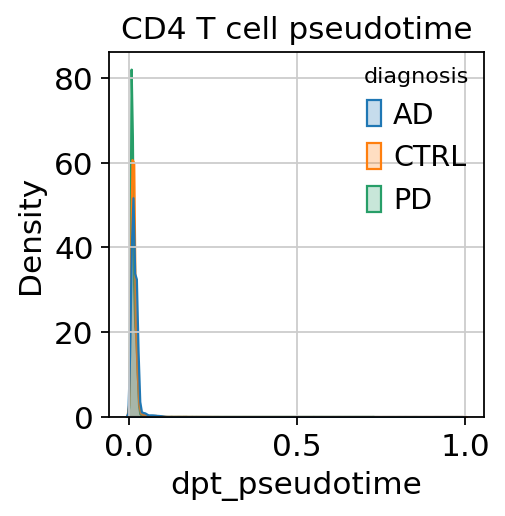

In [25]:
sns.kdeplot(data=adata_cd4.obs, x="dpt_pseudotime", hue="diagnosis", common_norm=False, fill=True)
plt.title("CD4 T cell pseudotime"); plt.show()

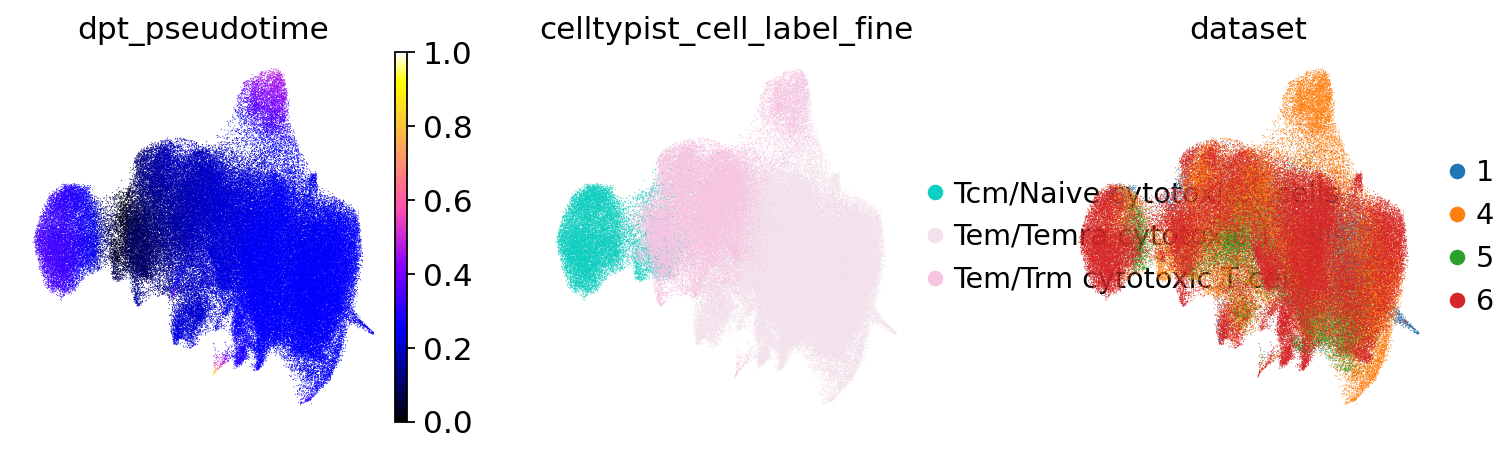

skipping genes not in var_names: ['CD8B']


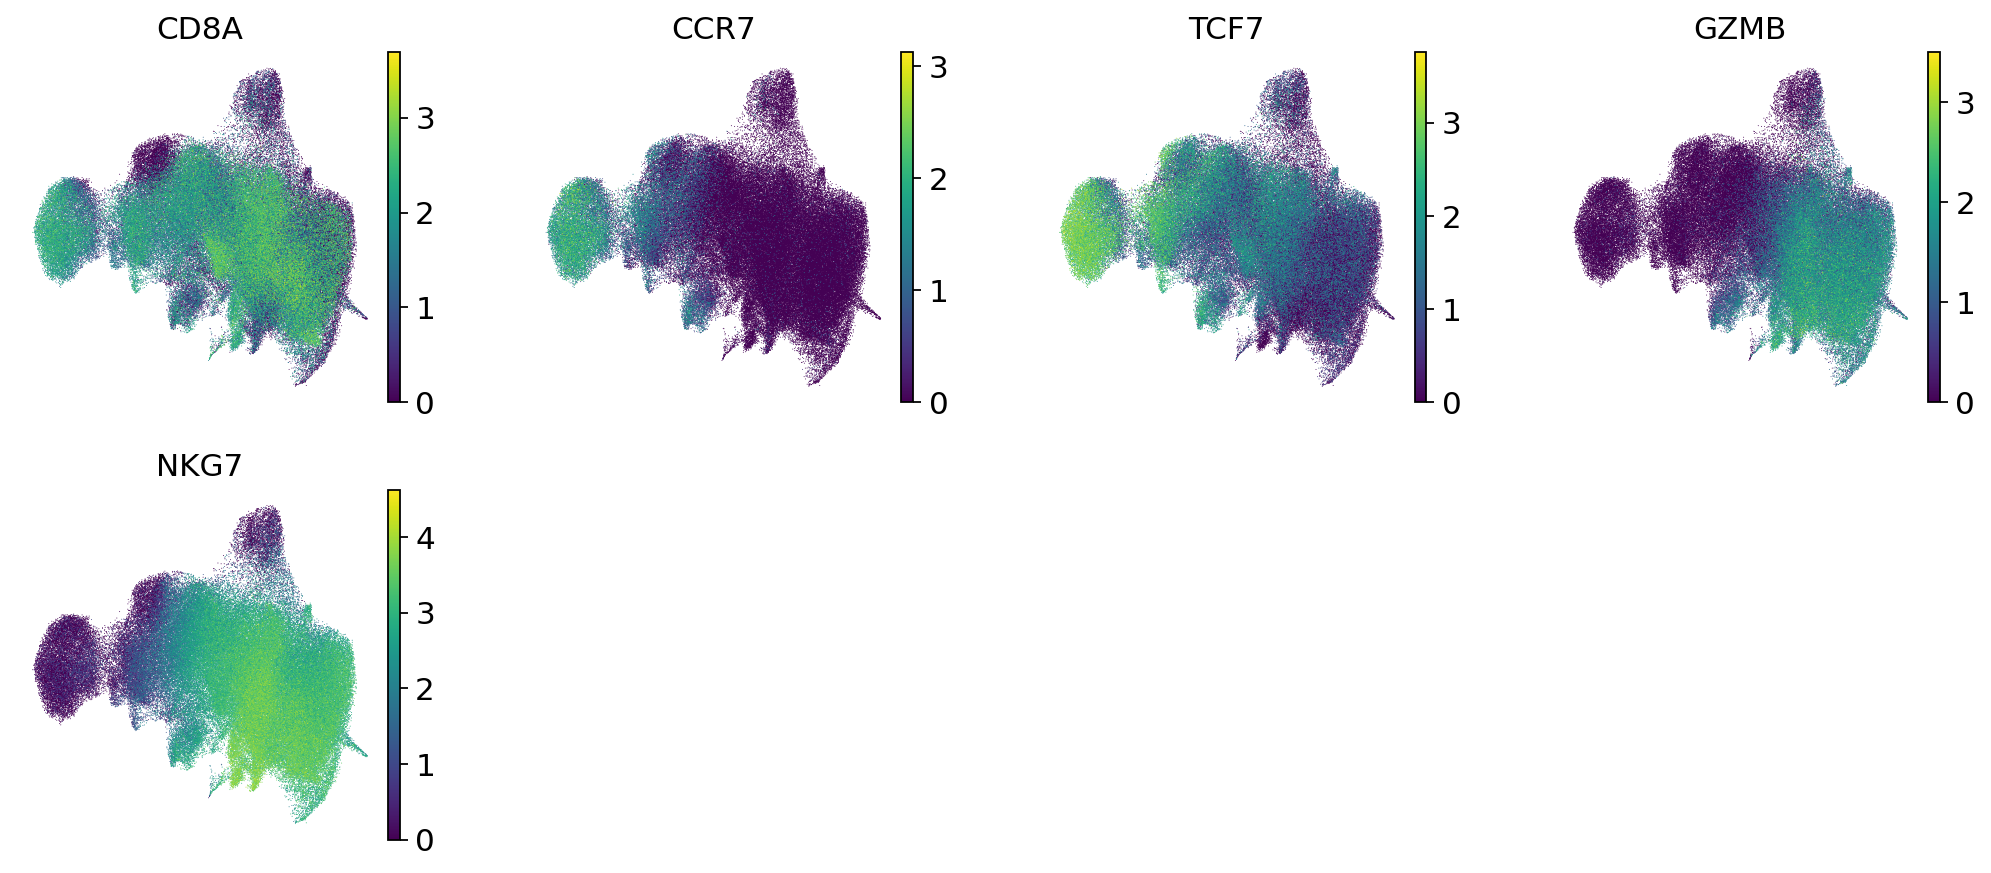

In [26]:
sc.pp.neighbors(adata_cd8, use_rep="X_scANVI") 
sc.tl.diffmap(adata_cd8) 

adata_cd8.uns["iroot"] = np.flatnonzero(
    adata_cd8.obs["celltypist_cell_label_fine"] == "Tcm/Naive cytotoxic T cells")[0]
sc.tl.dpt(adata_cd8) 
sc.tl.umap(adata_cd8)

sc.pl.embedding(adata_cd8, basis="umap",
                color=["dpt_pseudotime", "celltypist_cell_label_fine", "dataset"],
                color_map="gnuplot2")

cd8_markers = ["CD8A", "CD8B",   # lineage: confirm these are CD8 (not CD4)
               "CCR7", "TCF7",    # naive/early — HIGH at root
               "GZMB", "NKG7"]    # cytotoxic/effector — HIGH at terminal end

sc.pl.embedding(adata_cd8, basis="umap",
                color=present_genes(adata_cd8, cd8_markers),
                layer="log1p_norm")

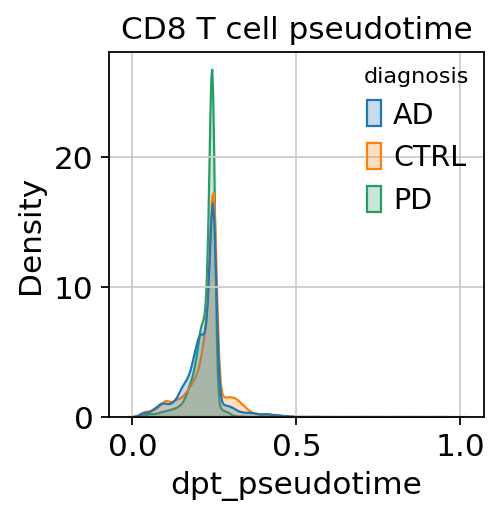

In [27]:
sns.kdeplot(data=adata_cd8.obs, x="dpt_pseudotime", hue="diagnosis", common_norm=False, fill=True)
plt.title("CD8 T cell pseudotime"); plt.show()


In [28]:
# #### Trying palantir
# import palantir

# # ## monocytes lineage

# # monocytes = ["Classical monocytes", "Non-classical monocytes"]
# # adata_mono = adata[adata.obs["celltypist_cell_label_fine"].isin(monocytes)].copy()

# # adata_mono

# # trying with coarse label

# adata_mono = adata[adata.obs["celltypist_cell_label_coarse"] == "Monocytes"].copy()


In [29]:
# import palantir
# import numpy as np

# # --- 1. Diffusion maps ON THE INTEGRATED LATENT (not fresh PCA) ---
# # pca_key tells Palantir which obsm to use as its input representation.
# dm_res = palantir.utils.run_diffusion_maps(
#     adata_mono, pca_key="X_scANVI", n_components=5
# )
# ms_data = palantir.utils.determine_multiscale_space(adata_mono)


In [30]:

# # --- 2. MAGIC imputation (only needed for gene-trend visualisation) ---
# # uses your normalised log layer as the thing to impute
# adata_mono.X = adata_mono.layers["log1p_norm"].copy()   # Palantir imputes .X
# imputed_X = palantir.utils.run_magic_imputation(adata_mono)


In [31]:

# # --- 3. Start cell = a classical monocyte (Palantir needs a cell NAME, not an index) ---
# classical = adata_mono.obs_names[
#     adata_mono.obs["celltypist_cell_label_fine"] == "Classical monocytes"]
# start_cell = classical[0]           # or pick the most extreme one (see caveat below)


In [32]:

# # --- 4. Run Palantir ---
# pr_res = palantir.core.run_palantir(
#     adata_mono, start_cell, num_waypoints=500
#     # terminal_states=... optional; let it auto-detect for a simple mono trajectory
# )


In [33]:

# # results land in adata_mono.obs["palantir_pseudotime"], ["palantir_entropy"], etc.
# sc.pl.embedding(adata_mono, basis="umap",
#                 color=["palantir_pseudotime", "palantir_entropy"])
